# MABSTRUCT GAMESTUDIO STUDY SHEET

implementing game studio via LangGraph study

## MABSTRUCT GAMESTUDIO CONCEPT

PRODUCER --> IDEATION --> DESIGN --> DEVELOP <--> TEST --> DEPLOYMENT


In [23]:
# Imports and environment first, as always

import os
import operator
import random
import requests
import uuid
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from pydantic import BaseModel, Field
from typing import List

from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.agents import create_agent



load_dotenv(override=True)

True

In [24]:
from langsmith import utils

utils.get_env_var.cache_clear()  # clear stale notebook cache

print("tracing:", utils.get_env_var("TRACING") or utils.get_env_var("TRACING_V2"))
print("project:", utils.get_env_var("PROJECT"))
print("endpoint:", utils.get_env_var("ENDPOINT"))
print("api key set:", bool(utils.get_env_var("API_KEY")))

tracing: true
project: GAMESTUDIO-STUDY
endpoint: https://eu.api.smith.langchain.com
api key set: True


In [25]:
# Getting the Telegram bot token and chat ID from environment variables
# You can also replace these with your actual values directly

TELEGRAM_BOT_TOKEN = os.getenv("TELEGRAM_BOT_TOKEN", "your_bot_token_here")
TELEGRAM_CHAT_ID = os.getenv("TELEGRAM_CHAT_ID", "your_chat_id_here")

### verify TELEGRAM token and chat_id are there

if TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID:
    print("TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found")
else:
    print("TELEGRAM_BOT_TOKEN or TELEGRAM_CHAT_ID not found")



TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found


In [26]:
def send_telegram_message(text):
    url = f"https://api.telegram.org/bot{TELEGRAM_BOT_TOKEN}/sendMessage"
    payload = {"chat_id": TELEGRAM_CHAT_ID, "text": text}
    response = requests.post(url, data=payload)

    if response.status_code == 200:
        # print("Message sent successfully!")
        return {"status": "success", "message": text}
    else:
        # print(f"Failed to send message. Status code: {response.status_code}")
        # print(response.text)
        return {"status": "error", "message": response.text}

## Adding tools


Adding Tavily Search.

Adding Telegram Push Tool.

In [27]:
from langchain_tavily import TavilySearch
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

search = TavilySearch(max_results=5)

@tool
def send_push_notification(text: str) -> str:
    """Send a short push notification to the user's phone."""
    send_telegram_message(text)
    return "Notification sent"


## Models, configurations and middleware to use 


In [133]:
import httpx
import anthropic
import openai
from langchain_anthropic import ChatAnthropic
from langchain.agents.middleware import ModelRetryMiddleware
from langchain_anthropic.middleware import AnthropicPromptCachingMiddleware

LLM_IDEATION_MODEL = ChatOpenAI(model="gpt-5.6-sol", reasoning_effort="none")
LLM_DESIGN_MODEL = ChatOpenAI(model="gpt-5.6-terra", reasoning_effort="none")

# Deployment is mechanical tool-calling (publish -> verify -> notify), not authoring.
LLM_DEPLOY_MODEL = ChatOpenAI(model="gpt-5.6-luna", reasoning_effort="none")

# Develop needs many long tool steps (start + js chunks + end + verify).
# The string form "anthropic:claude-opus-5" resolves to max_tokens=4096, which truncates
# tool arguments mid-JSON; Opus 5 supports up to 128k and runs adaptive thinking by default.
LLM_DEVELOP_OPUS_MODEL = ChatAnthropic(
    model="claude-opus-5",
    max_tokens=32000,
    streaming=True,               # required at large max_tokens to avoid HTTP timeouts
    effort="medium",              # trims thinking spend for mechanical code emission
    default_request_timeout=300,  # per-read idle timeout: fail fast on a stalled stream
    max_retries=2,
)

LLM_DEVELOP_FABLE_MODEL = ChatAnthropic(
    model="claude-fable-5",
    max_tokens=32000,
    streaming=True,
    effort="medium",
    default_request_timeout=300,
    max_retries=2,
)

# Same setup on the OpenAI client. Parameter names differ from ChatAnthropic:
#   max_tokens               -> max_tokens (alias of max_completion_tokens)  same name
#   effort                   -> reasoning_effort
#   default_request_timeout  -> request_timeout (alias: timeout)
# gpt-5.6-sol rejects any reasoning_effort other than "none" when function tools are
# bound on /v1/chat/completions. Either keep "none" (below), or switch to the Responses
# API to get real reasoning:  use_responses_api=True, reasoning_effort="low".
LLM_DEVELOP_GPT_MODEL = ChatOpenAI(
    model="gpt-5.6-sol",
    max_tokens=32000,
    streaming=True,
    reasoning_effort="none",
    request_timeout=300,
    max_retries=2,
)

# Swap this line to pick the develop model under test.
LLM_DEVELOP_MODEL = LLM_DEVELOP_OPUS_MODEL

DEVELOP_RECURSION_LIMIT = 200

# Transport faults surface while the SSE body is being consumed, which is outside the
# SDK retry loop (it covers sending the request and receiving headers only).
# Retrying here re-issues one model call instead of losing the whole build.
DEVELOP_TRANSPORT_ERRORS = (
    httpx.RemoteProtocolError,
    httpx.ReadError,
    httpx.ReadTimeout,
    anthropic.APIConnectionError,  # APITimeoutError subclasses this
    anthropic.InternalServerError,
    anthropic.RateLimitError,
    openai.APIConnectionError,     # APITimeoutError subclasses this
    openai.InternalServerError,
    openai.RateLimitError,
)

DEVELOP_MIDDLEWARE = [
    ModelRetryMiddleware(
        max_retries=3,
        retry_on=DEVELOP_TRANSPORT_ERRORS,
        on_failure="error",  # raise, so develop_node can still salvage the file on disk
        initial_delay=2.0,
    ),
]

# Anthropic-only: caches system prompt, tool schemas and the conversation prefix.
# On a non-Anthropic model it warns on every turn and caches nothing, so only add it
# when it applies. OpenAI caches long prefixes server-side with no configuration.
if isinstance(LLM_DEVELOP_MODEL, ChatAnthropic):
    DEVELOP_MIDDLEWARE.append(AnthropicPromptCachingMiddleware())

_dev_model_id = getattr(LLM_DEVELOP_MODEL, "model", None) or getattr(LLM_DEVELOP_MODEL, "model_name", "?")
print(f"develop model: {type(LLM_DEVELOP_MODEL).__name__} {_dev_model_id} | "
      f"middleware: {[type(m).__name__ for m in DEVELOP_MIDDLEWARE]}")


develop model: ChatAnthropic claude-opus-5 | middleware: ['ModelRetryMiddleware', 'AnthropicPromptCachingMiddleware']


## Ideation Agent

### A simple agent

In [29]:
GAME_TITLE = "The Big Swallow"


In [30]:
# OpenAI reasoning models: ChatOpenAI(..., reasoning_effort="none") when using tools.
# Anthropic: use ChatAnthropic (or the string "anthropic:claude-opus-4-6"), not ChatOpenAI.



MABSTRUCT_GAMESTUDIO_NAME = "MABSTRUCT GAMESTUDIO"

MABSTRUCT_GAMESTUDIO_BACKGROUNDER = f"""{MABSTRUCT_GAMESTUDIO_NAME}:
The studio concentrates on creating single player browser games.
The attitude of the games is creative, inventive and innovative and is slightly surreal 
and concentrates on sci-fi and cosmic themes.
"""

IDEATION_SYSTEM_PROMPT = f"""
You are an experienced Creative Strategist for web browser games for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
You have a strong background in browser games ideation and design.
You bring a wealth of knowledge about single player web browser games.
You are the one to bring back the best game ideas to the production team of the game studio.
You are known for your ability to create engaging, creative and fun browser games
that are both challenging and fun to play. You typically research the web for the latest trends and best games.
Genre, style, sub title and other criteria should be inventive. We are exploring game ideas.
These ideas will be later refined by the production and design team.
"""

IDEATION_HUMAN_PROMPT = """
Here is the new game title: {GAME_TITLE}.
Develop a list of 5 game ideas that are related to the game title.
Do not come back with less then 5 ideas.
For each game idea, provide a short description and the reason why this works for the studio.
You can also search the web for the latest trends and interesting new games.
"""


In [31]:
class GameIdea(BaseModel):
    """ a conceptual game idea """
    idea_id: str = Field(default="", description="Unique id assigned after ideation (not from the LLM)")
    sub_title: str = Field(description="a sub title for the game that triggers attention or interest to the player")
    genre: str = Field(description="game genre")
    style: str = Field(description="game style")
    reason: str = Field(description="reason why this idea is interesting and why it should be made")
    description: str = Field(description="an abstract to communicate the main idea of the game")
    features: list[str] = Field(description="features of the game")

class GameIdeaList(BaseModel):
    """ a list of game ideas """
    ideas: list[GameIdea] = Field(description="list of game ideas")


In [32]:
system_message = SystemMessage(IDEATION_SYSTEM_PROMPT)
human_message = HumanMessage(IDEATION_HUMAN_PROMPT.format(GAME_TITLE=GAME_TITLE))

messages_input = [
    human_message,
]

ideation_agent = create_agent(
    model=LLM_IDEATION_MODEL,
    system_prompt=IDEATION_SYSTEM_PROMPT,
    tools=[search],
    response_format=GameIdeaList,
)

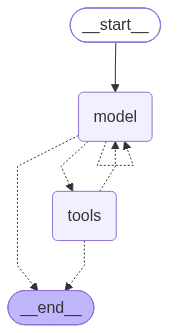

In [33]:
ideation_agent

### use it native (no graph)    

In [34]:
instruction = IDEATION_HUMAN_PROMPT.format(GAME_TITLE=GAME_TITLE)
agent_result = ideation_agent.invoke({
    "messages": [HumanMessage(content=instruction)]
})
ideas = agent_result["structured_response"].ideas

for idea in ideas:
    print(idea.sub_title)
    print(idea.description)
    print(idea.reason)
    print(idea.features)
    print(idea.genre)
    print(idea.style)
    print("-" * 100)

Eat the Universe Before It Eats You
Control a tiny gravitational mouth born inside a dying star. Swallow objects smaller than you to gain mass, but choose meals carefully: everything changes your body and abilities. A comet may grant an icy dash, a satellite may reveal hidden objects, and unstable antimatter may make you powerful—or split you in two. Each run escalates from space dust to planets, suns, and abstract laws of physics.
The instantly understandable “consume smaller things, evade larger things” premise suits short browser sessions, while roguelite mutations add replay value. Its escalating journey from microscopic debris to impossible celestial objects strongly matches the studio’s inventive cosmic identity.
['Mouse, touch, or keyboard movement with immediate arcade controls', 'Consumable objects that function as temporary upgrades and permanent mutations', 'Risk-reward digestion meter: overeating causes unstable transformations', 'Procedurally assembled cosmic regions and e

In [35]:
CHOSEN_IDEA_INDEX = 0

### now let us create a first graph

In [ ]:
class GameDesignBrief(BaseModel):
    """
    The brief for the game.
    """
    game_title: str = Field(description="The title of the game")
    game_sub_title: str = Field(description="The sub title of the game")
    game_description: str = Field(description="A short description of the game in 2 to 5 sentences.")
    game_genre: str = Field(description="The genre of the game")
    game_theme: str = Field(description="The theme of the game")
    game_mood: str = Field(description="The mood of the game")
    game_style: str = Field(description="The style of the game")
    game_goal: str = Field(description="The goal of the game for the player")
    game_objective: str = Field(description="The objective of the game for the player")
    game_rules: str = Field(description="The rules of the game")
    game_controls: str = Field(description="The controls of the game")
    game_instructions: str = Field(description="The instructions of the game")
    game_mechanics: str = Field(description="The mechanics of the game")
    game_sound: str = Field(description="The sound of the game")
    game_art: str = Field(description="Describe the distinctive creative art and style of the game")
    hints_for_the_team: str = Field(description="Hints and additional information for the production and design team")


class GameDesignRecord(BaseModel):
    """Design brief linked to one ideation idea."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    brief: GameDesignBrief


class DesignJob(TypedDict):
    """Input passed to each design worker via Send."""
    game_title: str
    idea_id: str
    idea: GameIdea


In [37]:
class GameDevelopRecord(BaseModel):
    """Built HTML game linked to one design brief."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    html_path: str = Field(description="Path to the written index.html")
    tier0_pass: bool = Field(description="Whether static Tier-0 validation passed")
    summary: str = Field(description="Developer confirmation: MVP vs deferred, validation notes")


class GameDeployRecord(BaseModel):
    """Live here.now site linked to one built game."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    slug: str = Field(default="", description="here.now slug — stable across re-deploys")
    site_url: str = Field(default="", description="Live URL for internal playtesting")
    deployed: bool = Field(description="Whether the game is live and verified")
    summary: str = Field(description="Deployment confirmation: URL, permanence, gate notes")


class GameStudioState(TypedDict):
    """
    The development state of the game studio.
    """
    game_title: str
    game_ideation: GameIdeaList | None
    game_designs: Annotated[list[GameDesignRecord], operator.add]
    game_developments: Annotated[list[GameDevelopRecord], operator.add]
    game_deployments: Annotated[list[GameDeployRecord], operator.add]
    game_html_path: str | None
    deployment_url: str | None

initial_state: GameStudioState = {
    "game_title": GAME_TITLE,
    "game_ideation": None,
    "game_designs": [],
    "game_developments": [],
    "game_deployments": [],
    "game_html_path": None,
    "deployment_url": None,
}

print(initial_state)

{'game_title': 'The Big Swallow', 'game_ideation': None, 'game_designs': [], 'game_developments': [], 'game_html_path': None}


In [38]:
def ideation_node(state: GameStudioState) -> dict:
    instruction = IDEATION_HUMAN_PROMPT.format(GAME_TITLE=state["game_title"])
    agent_result = ideation_agent.invoke({
        "messages": [HumanMessage(content=instruction)]
    })
    ideas = agent_result["structured_response"].ideas
    tagged_ideas = [
        idea.model_copy(update={"idea_id": str(uuid.uuid4())})
        for idea in ideas
    ]
    return {"game_ideation": GameIdeaList(ideas=tagged_ideas)}

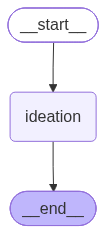

In [39]:
builder = StateGraph(GameStudioState)

builder.add_node("ideation", ideation_node)
builder.add_edge(START, "ideation")
builder.add_edge("ideation", END)
studio = builder.compile()

display(Image(studio.get_graph().draw_mermaid_png()))

In [41]:
result = studio.invoke(initial_state)
game_ideation = result["game_ideation"]


In [44]:
for idea in game_ideation.ideas:
    print(f"idea_id: {idea.idea_id}")
    print(idea.sub_title)
    print(idea.description)
    print(idea.reason)
    print(idea.features)
    print(idea.genre)
    print(idea.style)
    print("-" * 100)

idea_id: b236e7fc-01d7-4874-b2e1-910631076031
Eat the Universe Before It Eats You
Control a tiny gravitational mouth born at the edge of space. Swallow objects smaller than yourself, dodge larger predators, and digest unusual matter to mutate. Every meal alters your mass, movement, and abilities until you can challenge the creature swallowing the universe itself.
The instantly understandable “consume to grow” premise is ideal for browser play, while physics, mutations, and short procedural runs provide depth and replayability. Its strange cosmic ecosystem strongly matches MABSTRUCT’s inventive sci-fi identity.
['Mouse or touch-driven gravitational movement', 'Objects with distinct digestion effects', 'Mutation builds based on the player’s diet', 'Ten-to-fifteen-minute procedural runs', 'Bosses fought partly from inside their bodies', 'Persistent collection of bizarre cosmic recipes']
Physics-based action roguelite
Surreal cosmic minimalism with elastic animation and vivid neon matter
-

In [47]:
ideas = game_ideation.ideas
idea_chosen = ideas[CHOSEN_IDEA_INDEX]

In [49]:
idea_chosen

GameIdea(idea_id='b236e7fc-01d7-4874-b2e1-910631076031', sub_title='Eat the Universe Before It Eats You', genre='Physics-based action roguelite', style='Surreal cosmic minimalism with elastic animation and vivid neon matter', reason='The instantly understandable “consume to grow” premise is ideal for browser play, while physics, mutations, and short procedural runs provide depth and replayability. Its strange cosmic ecosystem strongly matches MABSTRUCT’s inventive sci-fi identity.', description='Control a tiny gravitational mouth born at the edge of space. Swallow objects smaller than yourself, dodge larger predators, and digest unusual matter to mutate. Every meal alters your mass, movement, and abilities until you can challenge the creature swallowing the universe itself.', features=['Mouse or touch-driven gravitational movement', 'Objects with distinct digestion effects', 'Mutation builds based on the player’s diet', 'Ten-to-fifteen-minute procedural runs', 'Bosses fought partly fro

### a graph with two nodes (ideation & design)

#### prompts

In [117]:


DESIGN_SYSTEM_PROMPT = f"""
You are an experienced Game Designer for web browser games for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
You have a strong background in browser games ideation and design.
You are known for your ability to create engaging, creative and fun browser games.
You create the best games design given the game idea and the title.
You create game design briefs for the production team to develop the game.

You create understandable games. The goals and achievments are clear to the player.
The rules and controls are clear to the player.
Instructions are clear and concise.
The game is fun and engaging.
The game is challenging and addictive.
The game is creative and innovative.
The game is unique and different.
The game is visually appealing.
The game is sound appealing.

The player can find the instructions from the game entry page.
The player can see the own score after when game is finished.
The player can see own progress and compare scores between own games.

"""

DESIGN_HUMAN_PROMPT = """
The task is to develop a game design brief for the following game:
The game title is {GAME_TITLE}.
The game idea is {GAME_IDEA}.
"""


#### the node

In [118]:
design_agent = create_agent(
    model=LLM_DESIGN_MODEL,
    system_prompt=DESIGN_SYSTEM_PROMPT,
    tools=[search],
    response_format=GameDesignBrief,
)


def design_node(state: GameStudioState) -> dict:
    instruction = DESIGN_HUMAN_PROMPT.format(GAME_TITLE=state["game_title"], GAME_IDEA=state["game_ideation"].ideas[0])
    #idea_id = state["game_ideation"].ideas[0].idea_id
    agent_result = design_agent.invoke({
        "messages": [HumanMessage(content=instruction)]
    })
    return {
            "game_designs": [
                GameDesignRecord(
                    idea_id=state["game_ideation"].ideas[CHOSEN_IDEA_INDEX].idea_id,
                    brief=agent_result["structured_response"],
                )
            ]
        }


#### the graph

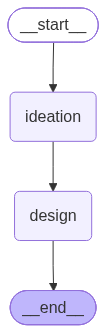

In [119]:
builder = StateGraph(GameStudioState)

builder.add_node("ideation", ideation_node)
builder.add_node("design", design_node)

builder.add_edge(START, "ideation")
builder.add_edge("ideation", "design")
builder.add_edge("design", END)

studio = builder.compile()

display(Image(studio.get_graph().draw_mermaid_png()))

#### run

In [120]:
initial_state: GameStudioState = {
    "game_title": GAME_TITLE,
    "game_ideation": None,
    "game_designs": [],
    "game_developments": [],
    "game_html_path": None,
    "test_result": None,
    "deployment_url": None,
}

result = studio.invoke(initial_state)

print(f"Ideas: {len(result['game_ideation'].ideas)}")
print(f"Designs: {len(result['game_designs'])}")
print()

for record in result["game_designs"]:
    idea = next(i for i in result["game_ideation"].ideas if i.idea_id == record.idea_id)
    print(f"idea_id: {record.idea_id}")
    print("game_title: ", initial_state["game_title"])
    print(f"brief.sub_title: {record.brief.game_sub_title}")
    print(f"brief.genre: {record.brief.game_genre}")
    print(f"brief.description: {record.brief.game_description}")
    print(f"brief.theme: {record.brief.game_theme}")
    print(f"brief.mood: {record.brief.game_mood}")
    print(f"brief.goal: {record.brief.game_goal}")
    print(f"brief.objective: {record.brief.game_objective}")
    print(f"brief.rules: {record.brief.game_rules}")
    print(f"brief.controls: {record.brief.game_controls}")
    print(f"brief.instructions: {record.brief.game_instructions}")
    print(f"brief.style: {record.brief.game_style}")
    print(f"brief.mechanics: {record.brief.game_mechanics}")
    print(f"brief.sound: {record.brief.game_sound}")
    print(f"brief.art: {record.brief.game_art}")
    print(f"brief.hints_for_the_team: {record.brief.hints_for_the_team}")
    print("-" * 100)

brief = result["game_designs"][0].brief


Ideas: 5
Designs: 1

idea_id: 38cff980-9c6b-4f35-82ea-fb3d4d428d81
game_title:  The Big Swallow
brief.sub_title: Eat the Universe Before It Eats You
brief.genre: Physics roguelite / cosmic arcade / momentum survival
brief.description: The Big Swallow is a fast, tactile physics roguelite in which the player controls a newborn black hole escaping a surreal cosmic laboratory. Slingshot through living solar systems, consume smaller bodies to expand your event horizon, and survive increasingly impossible celestial threats. Every object swallowed changes mass, velocity, and the fragile orbital balance of the sector around you.
brief.theme: Cosmic hunger, runaway growth, escaping containment, and the absurdity of a universe that can consume its own consumers.
brief.mood: Urgent, mischievous, awe-filled, strange, and lightly menacing. The player should feel like a tiny dangerous accident becoming an unstoppable cosmic appetite.
brief.goal: Escape the cosmic laboratory and reach the final outer

### develop agent + develop_one node

Parallel develop workers mirror `design_one`: each builds `{notebook_dir}/dev-output/{game_title}/{idea_id}/index.html` via chunked HTML tools + Tier-0 validation.

#### structured types

In [123]:
class GameDevelopRecord(BaseModel):
    """Built HTML game linked to one design brief."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    html_path: str = Field(description="Path to the written index.html")
    tier0_pass: bool = Field(description="Whether static Tier-0 validation passed")
    summary: str = Field(description="Developer confirmation: MVP vs deferred, validation notes")



#### prompts

In [134]:
DEVELOP_SYSTEM_PROMPT = f"""
You are an experienced Browser Game Developer for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
Build a complete single-file HTML5 Canvas game (inline CSS + vanilla JS).
Architecture requirements:
- Exactly ONE inline <script> block for all JavaScript
- Separate update(dt, state) from render(state) where possible
- Multiply physics by dt (frame-rate independent)
- Implement MVP scope only; list deferred items honestly in your final answer
Writing (use write_game_html_part tool only — never paste HTML in chat):
1. part=start: <!DOCTYPE html> through opening <script> (no </script> or </html> yet)
2. part=js: raw JavaScript chunks only (repeat 4-8 times, each under 6000 chars)
3. part=end: final JS plus </script></body></html> — this writes the file
After part=end, call verify_game_html. If Tier-0 FAIL, rewrite from part=start.
Final answer: short confirmation with path, byte size, Tier-0 status, MVP vs deferred list.
"""

DEVELOP_HUMAN_PROMPT = """
Game title: {GAME_TITLE}
Idea id: {IDEA_ID}

Develop this browser game from the design brief below.

Sub-title: {game_sub_title}
Genre: {game_genre}
Theme: {game_theme}
Style: {game_style}
Mood: {game_mood}
Description: {game_description}
Goal: {game_goal}
Objective: {game_objective}
Rules: {game_rules}
Controls: {game_controls}
Instructions: {game_instructions}
Mechanics: {game_mechanics}
Sound: {game_sound}
Art: {game_art}
Hints for the team: {hints_for_the_team}
"""

#### tools

In [135]:
from __future__ import annotations

from pathlib import Path
import re
import subprocess
import tempfile

NOTEBOOK_FILENAME = "mabstruct_studio.ipynb"


def _resolve_notebook_dir() -> tuple[Path, str]:
    """
    Directory holding this notebook, independent of the kernel's working directory.

    Jupyter starts a kernel in the notebook's own directory, but a kernel started from
    a terminal does not — and Path.cwd() would then scatter dev-output somewhere else
    (outside the .gitignore rule, in the worst case). These host signals carry the real
    notebook path:
      1. __vsc_ipynb_file__  — set by VS Code / Cursor
      2. __session__         — set by JupyterLab / Notebook 7 from JPY_SESSION_NAME
    Failing both, walk up from cwd looking for the notebook file itself.
    """
    for name, value in (
        ("__vsc_ipynb_file__", globals().get("__vsc_ipynb_file__")),
        ("__session__", globals().get("__session__")),
        ("JPY_SESSION_NAME", os.environ.get("JPY_SESSION_NAME")),
    ):
        if not value:
            continue
        path = Path(value).expanduser()
        if not path.is_absolute():
            path = Path.cwd() / path
        if path.suffix == ".ipynb" and path.parent.is_dir():
            return path.parent.resolve(), name

    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base, base / "mabstruct_studio"):
            if (candidate / NOTEBOOK_FILENAME).exists():
                return candidate.resolve(), f"located {NOTEBOOK_FILENAME}"

    return here, "cwd fallback — notebook not found"


NOTEBOOK_DIR, _NOTEBOOK_DIR_SOURCE = _resolve_notebook_dir()
STUDIO_OUTPUT_DIR = NOTEBOOK_DIR / "dev-output"

print(f"NOTEBOOK_DIR:      {NOTEBOOK_DIR}  (via {_NOTEBOOK_DIR_SOURCE})")
print(f"STUDIO_OUTPUT_DIR: {STUDIO_OUTPUT_DIR}")
if _NOTEBOOK_DIR_SOURCE.startswith("cwd fallback"):
    print("WARNING: could not locate the notebook; using the working directory above.")
MAX_JS_CHUNK_CHARS = 6000
SCRIPT_BLOCK_RE = re.compile(
    r"<script(?![^>]*\bsrc=)[^>]*>(.*?)</script>",
    re.IGNORECASE | re.DOTALL,
)

def _game_html_path(game_title: str, idea_id: str) -> Path:
    return STUDIO_OUTPUT_DIR / game_title / idea_id / "index.html"


def run_static_validation(html_path: Path) -> dict:
    """Tier 0: single inline script block + node --check when available."""
    issues: list[str] = []
    checks: dict = {}

    if not html_path.exists():
        return {"pass": False, "issues": [f"missing file: {html_path}"], "checks": checks}

    html = html_path.read_text(encoding="utf-8")
    checks["bytes"] = len(html)
    script_blocks = [
        block.strip()
        for block in SCRIPT_BLOCK_RE.findall(html)
        if block.strip()
    ]
    checks["script_blocks"] = len(script_blocks)
    if len(script_blocks) != 1:
        issues.append(
            f"expected exactly 1 inline <script> block, found {len(script_blocks)}"
        )

    for index, block in enumerate(script_blocks):
        with tempfile.NamedTemporaryFile(
            mode="w", suffix=f"_{index}.js", delete=False, encoding="utf-8"
        ) as tmp:
            tmp.write(block)
            tmp_path = Path(tmp.name)
        try:
            proc = subprocess.run(
                ["node", "--check", str(tmp_path)],
                capture_output=True,
                text=True,
                timeout=10,
            )
            if proc.returncode != 0:
                message = (proc.stderr or proc.stdout or "parse failed").strip()
                issues.append(f"script block {index}: {message}")
        except FileNotFoundError:
            issues.append("node is not installed — cannot run JS parse check")
            break
        except subprocess.TimeoutExpired:
            issues.append(f"script block {index}: node --check timed out")
        finally:
            tmp_path.unlink(missing_ok=True)

    return {"pass": not issues, "issues": issues, "checks": checks}


def make_dev_tools(game_title: str, idea_id: str) -> list:
    """Per-idea HTML assembly tools (safe for parallel develop workers)."""
    buffer: list[str] = []

    @tool
    def write_game_html_part(content: str, part: str) -> str:
        """Assemble a single-file HTML game across start → js chunks → end."""
        nonlocal buffer

        if not content or not str(content).strip():
            return "Write rejected: content is empty."

        normalized = part.strip().lower()
        if normalized not in {"start", "js", "end"}:
            return 'Write rejected: part must be "start", "js", or "end".'

        if normalized in {"start", "js"} and len(content) > MAX_JS_CHUNK_CHARS:
            return (
                f"Write rejected: chunk too large ({len(content)} chars). "
                f"Split into pieces under {MAX_JS_CHUNK_CHARS} characters."
            )

        if normalized == "start":
            buffer.clear()
            lower = content.lower()
            if not lower.lstrip().startswith("<!doctype html"):
                return "Write rejected: start must begin with <!DOCTYPE html>"
            if "<script" not in lower:
                return "Write rejected: start must open exactly one <script> block"
            if "</script>" in lower or "</html>" in lower:
                return (
                    "Write rejected: start must NOT close </script> or </html>. "
                    "Use part=js for code and part=end for closing tags."
                )
            buffer.append(content)
            return f"Buffered start ({len(content)} chars). Next: part=js, then part=end."

        if normalized == "js":
            if not buffer:
                return "Write rejected: call part=start before part=js."
            lower = content.lower()
            for tag in ("<script", "</script>", "</html>", "<!doctype", "</body>", "<body"):
                if tag in lower:
                    return f"Write rejected: js part must be raw JavaScript only (found {tag})."
            buffer.append(content)
            total = sum(len(piece) for piece in buffer)
            return f"Buffered js ({len(content)} chars). Assembly total: {total} chars."

        if not buffer:
            return "Write rejected: call part=start before part=end."
        lower = content.lower()
        if "</script>" not in lower or "</html>" not in lower:
            return "Write rejected: end must include </script></body></html>."

        buffer.append(content)
        full = "".join(buffer)
        path = _game_html_path(game_title, idea_id)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(full, encoding="utf-8")
        buffer.clear()

        validation = run_static_validation(path)
        status = "PASS" if validation["pass"] else "FAIL"
        lines = [
            f"Wrote {path} ({len(full)} bytes)",
            f"Tier-0 validation: {status}",
        ]
        if validation["issues"]:
            lines.append("Issues: " + "; ".join(validation["issues"]))
        elif validation["pass"]:
            lines.append("Single inline script block parsed successfully.")
        if not validation["pass"]:
            lines.append("Fix issues and rewrite using part=start again.")
        return "\n".join(lines)

    @tool
    def verify_game_html() -> str:
        """Run Tier-0 validation on the current idea's index.html."""
        path = _game_html_path(game_title, idea_id)
        validation = run_static_validation(path)
        status = "PASS" if validation["pass"] else "FAIL"
        lines = [f"Tier-0 validation: {status}", f"File: {path}"]
        if validation["issues"]:
            lines.append("Issues:")
            lines.extend(f"- {issue}" for issue in validation["issues"])
        return "\n".join(lines)

    return [write_game_html_part, verify_game_html]


def _message_text(message) -> str:
    """Plain text from AIMessage; Opus may return thinking blocks as a list."""
    content = message.content
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts: list[str] = []
        for block in content:
            if isinstance(block, dict) and block.get("type") == "text":
                parts.append(block.get("text", ""))
            elif isinstance(block, str):
                parts.append(block)
        return "\n".join(part for part in parts if part)
    return str(content)


def _tool_names_from_messages(messages) -> list[str]:
    names: list[str] = []
    for msg in messages:
        tool_calls = getattr(msg, "tool_calls", None) or []
        for tc in tool_calls:
            names.append(tc.get("name", "?"))
    return names




NOTEBOOK_DIR:      /Users/mab/dev/agents/pingmab-agents/mabstruct_studio  (via __vsc_ipynb_file__)
STUDIO_OUTPUT_DIR: /Users/mab/dev/agents/pingmab-agents/mabstruct_studio/dev-output


#### the develop node

In [137]:

def develop_node(state: GameStudioState) -> dict:
    game_title = state["game_title"]
    idea_id = state["game_ideation"][0].idea_id
    design = state["game_designs"][0]

    html_path = _game_html_path(game_title, idea_id)
    print(f"html_path: {html_path}")

    # A file left behind by an earlier run would otherwise be mistaken for this run's
    # output — and a half-written file from a crash would be mistaken for a build.
    html_path.parent.mkdir(parents=True, exist_ok=True)
    html_path.unlink(missing_ok=True)

    develop_agent = create_agent(
        model=LLM_DEVELOP_MODEL,
        system_prompt=DEVELOP_SYSTEM_PROMPT,
        tools=make_dev_tools(game_title, idea_id),
        middleware=DEVELOP_MIDDLEWARE,
    )

    instruction = DEVELOP_HUMAN_PROMPT.format(
        GAME_TITLE=game_title,
        IDEA_ID=idea_id,
        game_sub_title=design.game_sub_title,
        game_genre=design.game_genre,
        game_theme=design.game_theme,
        game_mood=design.game_mood,
        game_style=design.game_style,
        game_description=design.game_description,
        game_goal=design.game_goal,
        game_objective=design.game_objective,
        game_rules=design.game_rules,
        game_controls=design.game_controls,
        game_instructions=design.game_instructions,
        game_mechanics=design.game_mechanics,
        game_sound=design.game_sound,
        game_art=design.game_art,
        hints_for_the_team=design.hints_for_the_team,
    )

    agent_config = {"recursion_limit": DEVELOP_RECURSION_LIMIT}

    def _run(messages):
        """One agent run. A dead stream costs the turn, not the file already on disk."""
        try:
            return develop_agent.invoke({"messages": messages}, config=agent_config)
        except Exception as exc:
            print(f"develop invoke failed: {type(exc).__name__}: {exc}")
            return None

    def _validate() -> dict:
        return (
            run_static_validation(html_path)
            if html_path.exists()
            else {"pass": False, "issues": ["file not written"]}
        )

    agent_result = _run([HumanMessage(content=instruction)])
    validation = _validate()

    # One repair turn that continues the same conversation — never a second full build.
    if not validation["pass"] and agent_result is not None:
        if not html_path.exists():
            note = (
                "CRITICAL: index.html was NOT written. Use write_game_html_part only — "
                "part=start, then part=js (repeat 4-8 times), then part=end to write the "
                "file. Then call verify_game_html. Do not paste HTML in chat."
            )
        else:
            note = (
                "Tier-0 validation FAILED: " + "; ".join(validation["issues"]) + "\n"
                "Rewrite from part=start with that issue fixed, then call verify_game_html."
            )
        agent_result = _run(list(agent_result["messages"]) + [HumanMessage(content=note)])
        validation = _validate()

    messages = list(agent_result["messages"]) if agent_result else []
    summary = _message_text(messages[-1]) if messages else "develop agent produced no messages"
    if not validation["pass"]:
        summary = (
            f"{summary}\n\nTier-0 issues: {'; '.join(validation['issues'])}\n"
            f"Tools called: {_tool_names_from_messages(messages) or ['none']}"
        )

    return {
        "game_developments": [
            GameDevelopRecord(
                idea_id=idea_id,
                html_path=str(html_path.resolve()),
                tier0_pass=validation["pass"],
                summary=summary,
            )
        ]
    }


#### the singular dev graph (testing)

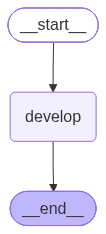

In [138]:
dev_builder = StateGraph(GameStudioState)

dev_builder.add_node("develop", develop_node)

#dev_builder.add_conditional_edges(START, fan_out_develop)
dev_builder.add_edge(START, "develop")
dev_builder.add_edge("develop", END)

dev_studio = dev_builder.compile()

display(Image(dev_studio.get_graph().draw_mermaid_png()))

In [139]:
ideas

[GameIdea(idea_id='b236e7fc-01d7-4874-b2e1-910631076031', sub_title='Eat the Universe Before It Eats You', genre='Physics-based action roguelite', style='Surreal cosmic minimalism with elastic animation and vivid neon matter', reason='The instantly understandable “consume to grow” premise is ideal for browser play, while physics, mutations, and short procedural runs provide depth and replayability. Its strange cosmic ecosystem strongly matches MABSTRUCT’s inventive sci-fi identity.', description='Control a tiny gravitational mouth born at the edge of space. Swallow objects smaller than yourself, dodge larger predators, and digest unusual matter to mutate. Every meal alters your mass, movement, and abilities until you can challenge the creature swallowing the universe itself.', features=['Mouse or touch-driven gravitational movement', 'Objects with distinct digestion effects', 'Mutation builds based on the player’s diet', 'Ten-to-fifteen-minute procedural runs', 'Bosses fought partly fr

In [140]:
dev_state = initial_state.copy()

dev_state["game_ideation"] = ideas
dev_state["game_designs"] = [brief]

print(dev_state)

{'game_title': 'The Big Swallow', 'game_ideation': [GameIdea(idea_id='b236e7fc-01d7-4874-b2e1-910631076031', sub_title='Eat the Universe Before It Eats You', genre='Physics-based action roguelite', style='Surreal cosmic minimalism with elastic animation and vivid neon matter', reason='The instantly understandable “consume to grow” premise is ideal for browser play, while physics, mutations, and short procedural runs provide depth and replayability. Its strange cosmic ecosystem strongly matches MABSTRUCT’s inventive sci-fi identity.', description='Control a tiny gravitational mouth born at the edge of space. Swallow objects smaller than yourself, dodge larger predators, and digest unusual matter to mutate. Every meal alters your mass, movement, and abilities until you can challenge the creature swallowing the universe itself.', features=['Mouse or touch-driven gravitational movement', 'Objects with distinct digestion effects', 'Mutation builds based on the player’s diet', 'Ten-to-fiftee

In [141]:
print(dev_state.get("game_ideation"))

[GameIdea(idea_id='b236e7fc-01d7-4874-b2e1-910631076031', sub_title='Eat the Universe Before It Eats You', genre='Physics-based action roguelite', style='Surreal cosmic minimalism with elastic animation and vivid neon matter', reason='The instantly understandable “consume to grow” premise is ideal for browser play, while physics, mutations, and short procedural runs provide depth and replayability. Its strange cosmic ecosystem strongly matches MABSTRUCT’s inventive sci-fi identity.', description='Control a tiny gravitational mouth born at the edge of space. Swallow objects smaller than yourself, dodge larger predators, and digest unusual matter to mutate. Every meal alters your mass, movement, and abilities until you can challenge the creature swallowing the universe itself.', features=['Mouse or touch-driven gravitational movement', 'Objects with distinct digestion effects', 'Mutation builds based on the player’s diet', 'Ten-to-fifteen-minute procedural runs', 'Bosses fought partly fr

In [142]:
devs = dev_state.get("game_developments")
devs


[]

In [143]:
dev_result = dev_studio.invoke(dev_state)

html_path: /Users/mab/dev/agents/pingmab-agents/mabstruct_studio/dev-output/The Big Swallow/b236e7fc-01d7-4874-b2e1-910631076031/index.html


In [77]:
dev_result

{'game_title': 'The Big Swallow',
 'game_ideation': [GameIdea(idea_id='b236e7fc-01d7-4874-b2e1-910631076031', sub_title='Eat the Universe Before It Eats You', genre='Physics-based action roguelite', style='Surreal cosmic minimalism with elastic animation and vivid neon matter', reason='The instantly understandable “consume to grow” premise is ideal for browser play, while physics, mutations, and short procedural runs provide depth and replayability. Its strange cosmic ecosystem strongly matches MABSTRUCT’s inventive sci-fi identity.', description='Control a tiny gravitational mouth born at the edge of space. Swallow objects smaller than yourself, dodge larger predators, and digest unusual matter to mutate. Every meal alters your mass, movement, and abilities until you can challenge the creature swallowing the universe itself.', features=['Mouse or touch-driven gravitational movement', 'Objects with distinct digestion effects', 'Mutation builds based on the player’s diet', 'Ten-to-fifte

### deployment agent + deployment node

Publishes the built `index.html` to here.now so the internal playtest circle can open it in a browser. Each game keeps one stable URL: the site is created once per `idea_id` and updated in place on every later run, with the slug remembered in `dev-output/{game_title}/{idea_id}/herenow.json`.


#### structured types

In [111]:
class GameDeployRecord(BaseModel):
    """Live here.now site linked to one built game."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    slug: str = Field(default="", description="here.now slug — stable across re-deploys")
    site_url: str = Field(default="", description="Live URL for internal playtesting")
    deployed: bool = Field(description="Whether the game is live and verified")
    summary: str = Field(description="Deployment confirmation: URL, permanence, gate notes")

#### prompts

In [112]:
DEPLOYMENT_SYSTEM_PROMPT = f"""
You are the Deployment Engineer for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
You publish finished single-file HTML5 games to here.now so the studio's small internal
playtest circle can open them in a browser. Builds are unlisted: live on a public link
that is shared with the circle only — never announced, never indexed.
Sequence (use the tools; never state a URL you were not handed by a tool):
1. publish_game_site — publishes this idea's index.html and returns the live URL
2. verify_deployed_site — confirms here.now is really serving the game
3. send_push_notification — tell the studio lead the build is ready, with the URL
If publish_game_site rejects the build, stop there: report why, and do not notify.
Each game keeps one stable URL; re-deploying updates that same site in place.
Final answer: live URL, permanent vs temporary, verification result, notification status.
"""

DEPLOYMENT_HUMAN_PROMPT = """
Game title: {GAME_TITLE}
Idea id: {IDEA_ID}
Sub-title: {game_sub_title}

This build passed Tier-0 validation and is ready for internal playtesting.
Deploy it to here.now and notify the studio lead.
"""

#### tools

In [113]:
import hashlib
import json
import time

HERENOW_BASE_URL = "https://here.now"
HERENOW_CLIENT = "langgraph/mabstruct_studio"
HERENOW_TIMEOUT = 60
HERENOW_UPLOAD_TIMEOUT = 180

# A build that failed Tier-0 is broken JavaScript. Publishing it only wastes a
# playtester's time, so the gate is on by default — flip it to ship a known-broken
# build on purpose.
DEPLOY_REQUIRE_TIER0 = True


def _herenow_api_key() -> str | None:
    """
    The parent repo's .env names this HERE_NOW_API_KEY, while the here.now skill and the
    CrewAI studio tool both read HERENOW_API_KEY — that mismatch is why earlier deploys
    silently fell back to anonymous. Accept either spelling, then the credentials file.

    Without a key every publish is an anonymous site that expires after 24 hours.
    """
    for var in ("HERE_NOW_API_KEY", "HERENOW_API_KEY"):
        value = os.getenv(var)
        if value and value.strip():
            return value.strip()

    credentials = Path.home() / ".herenow" / "credentials"
    if credentials.exists():
        return credentials.read_text(encoding="utf-8").strip() or None

    return None


def _herenow_headers() -> dict:
    headers = {"Content-Type": "application/json", "X-HereNow-Client": HERENOW_CLIENT}
    api_key = _herenow_api_key()
    if api_key:
        headers["Authorization"] = f"Bearer {api_key}"
    return headers


def _herenow_registry_path(game_title: str, idea_id: str) -> Path:
    """Slug registry, written beside the game it names (disposable like the rest of dev-output)."""
    return _game_html_path(game_title, idea_id).parent / "herenow.json"


def _read_herenow_registry(game_title: str, idea_id: str) -> dict:
    path = _herenow_registry_path(game_title, idea_id)
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        return {}


def _write_herenow_registry(game_title: str, idea_id: str, record: dict) -> None:
    path = _herenow_registry_path(game_title, idea_id)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(record, indent=2), encoding="utf-8")


def _herenow_finalize(slug: str, version_id: str, finalize_url: str | None) -> dict:
    """
    Nothing is live until finalize succeeds. It is idempotent by versionId, and answers
    409 finalize_in_flight + Retry-After while another finalize holds the same version —
    that is a "wait and retry", not a failure.
    """
    url = finalize_url or f"{HERENOW_BASE_URL}/api/v1/publish/{slug}/finalize"

    for _ in range(4):
        response = requests.post(
            url,
            json={"versionId": version_id},
            headers=_herenow_headers(),
            timeout=HERENOW_TIMEOUT,
        )
        if response.status_code == 409 and "finalize_in_flight" in response.text:
            time.sleep(float(response.headers.get("Retry-After", 3)))
            continue
        response.raise_for_status()
        return response.json()

    raise RuntimeError(f"finalize kept reporting finalize_in_flight for slug {slug}")


def _publish_html_to_herenow(
    html_path: Path,
    display_name: str = "",
    display_description: str = "",
    slug: str = "",
) -> dict:
    """
    Three-step here.now publish: create/update -> upload -> finalize.

    here.now does not let a caller choose its slug (PublishCreateRequest has no slug
    field), so a stable per-game URL means creating the site once and updating that
    slug forever after via PUT /api/v1/publish/{slug}.
    """
    data = html_path.read_bytes()
    body: dict = {
        "files": [
            {
                "path": "index.html",
                "size": len(data),
                "contentType": "text/html",
                "hash": hashlib.sha256(data).hexdigest(),
            }
        ]
    }
    if display_name:
        body["displayName"] = display_name[:80]
    if display_description:
        body["displayDescription"] = display_description[:280]

    headers = _herenow_headers()
    created = None

    if slug:
        response = requests.put(
            f"{HERENOW_BASE_URL}/api/v1/publish/{slug}",
            json=body,
            headers=headers,
            timeout=HERENOW_TIMEOUT,
        )
        if response.status_code == 404:
            slug = ""  # the registry names a site that no longer exists — create a new one
        else:
            response.raise_for_status()
            created = response.json()

    if created is None:
        response = requests.post(
            f"{HERENOW_BASE_URL}/api/v1/publish",
            json=body,
            headers=headers,
            timeout=HERENOW_TIMEOUT,
        )
        response.raise_for_status()
        created = response.json()

    upload = created["upload"]
    version_id = upload["versionId"]

    # Re-publishing identical bytes deduplicates server-side: the file lands in
    # `skipped` with no upload target, so drive the loop off `uploads`, not the manifest.
    for target in upload["uploads"]:
        put_headers = dict(target.get("headers", {}))
        if not any(key.lower() == "content-type" for key in put_headers):
            put_headers["Content-Type"] = "text/html"
        put_response = requests.put(
            target["url"],
            data=data,
            headers=put_headers,
            timeout=HERENOW_UPLOAD_TIMEOUT,
        )
        put_response.raise_for_status()

    finalized = _herenow_finalize(created["slug"], version_id, upload.get("finalizeUrl"))

    return {
        "slug": finalized.get("slug") or created["slug"],
        "site_url": finalized.get("siteUrl") or created.get("siteUrl", ""),
        "version_id": finalized.get("currentVersionId", version_id),
        "anonymous": bool(created.get("anonymous", _herenow_api_key() is None)),
        "claim_url": created.get("claimUrl", ""),
        "expires_at": created.get("expiresAt"),
        "unchanged": bool(finalized.get("unchanged")),
        "updated_existing": bool(slug),
    }


def make_deploy_tools(game_title: str, idea_id: str, sub_title: str = "") -> list:
    """Per-idea here.now deployment tools (mirrors make_dev_tools)."""

    @tool
    def publish_game_site() -> str:
        """Publish this idea's built index.html to here.now and return the live URL.

        Creates the site on first use and updates the same slug on every later run, so
        the game keeps one stable URL. Call verify_deployed_site afterwards.
        """
        html_path = _game_html_path(game_title, idea_id)
        if not html_path.exists():
            return f"Publish rejected: no built game at {html_path}."

        validation = run_static_validation(html_path)
        if DEPLOY_REQUIRE_TIER0 and not validation["pass"]:
            return (
                "Publish rejected: Tier-0 validation failed — "
                + "; ".join(validation["issues"])
            )

        registry = _read_herenow_registry(game_title, idea_id)
        try:
            result = _publish_html_to_herenow(
                html_path,
                display_name=f"{game_title} — {MABSTRUCT_GAMESTUDIO_NAME}",
                display_description=sub_title,
                slug=registry.get("slug", ""),
            )
        except requests.HTTPError as exc:
            status = exc.response.status_code if exc.response is not None else "?"
            detail = exc.response.text[:400] if exc.response is not None else str(exc)
            return f"Publish failed: HTTP {status}: {detail}"
        except Exception as exc:
            return f"Publish failed: {type(exc).__name__}: {exc}"

        _write_herenow_registry(
            game_title,
            idea_id,
            {
                "slug": result["slug"],
                "site_url": result["site_url"],
                "version_id": result["version_id"],
                "anonymous": result["anonymous"],
                "updated_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
            },
        )

        lines = [
            f"Published {html_path.name} ({len(html_path.read_bytes())} bytes)",
            f"Live URL: {result['site_url']}",
            f"Slug: {result['slug']} ({'updated in place' if result['updated_existing'] else 'newly created'})",
        ]
        if result["anonymous"]:
            lines.append("Temporary site: expires in 24 hours (no API key found).")
            if result["claim_url"]:
                lines.append(f"Claim URL (shown once): {result['claim_url']}")
        else:
            lines.append("Permanent site: saved to the studio account.")
        if result["unchanged"]:
            lines.append("Content identical to the live version — no new version created.")
        lines.append("Access: public link, unlisted — share the URL only with the playtest circle.")
        return "\n".join(lines)

    @tool
    def verify_deployed_site() -> str:
        """Fetch the deployed URL and confirm here.now is really serving this game."""
        registry = _read_herenow_registry(game_title, idea_id)
        site_url = registry.get("site_url")
        if not site_url:
            return "Verify rejected: nothing published yet — call publish_game_site first."

        try:
            response = requests.get(site_url, timeout=30)
        except Exception as exc:
            return f"Verify FAILED: {type(exc).__name__}: {exc}"

        if response.status_code != 200:
            return f"Verify FAILED: {site_url} returned HTTP {response.status_code}"

        body = response.text.lower()
        missing = [marker for marker in ("<!doctype html", "<canvas", "<script") if marker not in body]
        if missing:
            return (
                f"Verify FAILED: {site_url} served HTTP 200 but is missing {', '.join(missing)} "
                f"({len(response.text)} bytes) — that is probably not the game."
            )

        return f"Verify PASS: {site_url} serving {len(response.text)} bytes of game HTML."

    return [publish_game_site, verify_deployed_site, send_push_notification]

#### the deployment node

In [114]:
def deployment_node(state: GameStudioState) -> dict:
    game_title = state["game_title"]
    idea_id = state["game_ideation"][CHOSEN_IDEA_INDEX].idea_id
    design = state["game_designs"][CHOSEN_IDEA_INDEX]

    html_path = _game_html_path(game_title, idea_id)
    print(f"deploying: {html_path}")

    def _record(deployed: bool, summary: str, registry: dict | None = None) -> dict:
        registry = registry or {}
        return {
            "game_deployments": [
                GameDeployRecord(
                    idea_id=idea_id,
                    slug=registry.get("slug", ""),
                    site_url=registry.get("site_url", ""),
                    deployed=deployed,
                    summary=summary,
                )
            ],
            "deployment_url": registry.get("site_url"),
        }

    # The gate is deterministic, not the agent's call: a build that failed Tier-0 is
    # broken JavaScript. Recorded as a skipped deploy rather than raised, so the graph
    # still finishes with an honest record.
    develop_record = next(
        (d for d in state.get("game_developments", []) if d.idea_id == idea_id),
        None,
    )
    if DEPLOY_REQUIRE_TIER0 and develop_record is not None and not develop_record.tier0_pass:
        return _record(False, "Deploy skipped: build failed Tier-0 validation.")

    if not html_path.exists():
        return _record(False, f"Deploy skipped: no build found at {html_path}.")

    deploy_agent = create_agent(
        model=LLM_DEPLOY_MODEL,
        system_prompt=DEPLOYMENT_SYSTEM_PROMPT,
        tools=make_deploy_tools(game_title, idea_id, sub_title=design.game_sub_title),
    )

    instruction = DEPLOYMENT_HUMAN_PROMPT.format(
        GAME_TITLE=game_title,
        IDEA_ID=idea_id,
        game_sub_title=design.game_sub_title,
    )

    try:
        agent_result = deploy_agent.invoke({"messages": [HumanMessage(content=instruction)]})
    except Exception as exc:
        print(f"deploy invoke failed: {type(exc).__name__}: {exc}")
        agent_result = None

    # The registry file is the source of truth for what actually went live — an agent
    # can describe a deploy it never made, but only publish_game_site writes this.
    registry = _read_herenow_registry(game_title, idea_id)
    messages = list(agent_result["messages"]) if agent_result else []
    summary = _message_text(messages[-1]) if messages else "deploy agent produced no messages"

    if not registry.get("site_url"):
        summary = (
            f"{summary}\n\nNo live URL was recorded — the publish tool never succeeded.\n"
            f"Tools called: {_tool_names_from_messages(messages) or ['none']}"
        )
        return _record(False, summary, registry)

    if registry.get("anonymous"):
        summary = f"{summary}\n\nWARNING: anonymous site — expires 24h after publish."

    return _record(True, summary, registry)

#### the singular deploy graph (testing)

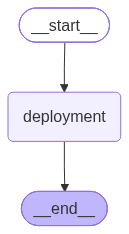

In [115]:
deploy_builder = StateGraph(GameStudioState)

deploy_builder.add_node("deployment", deployment_node)

deploy_builder.add_edge(START, "deployment")
deploy_builder.add_edge("deployment", END)

deploy_studio = deploy_builder.compile()

display(Image(deploy_studio.get_graph().draw_mermaid_png()))

In [116]:
deploy_state = dev_state.copy()
deploy_state["game_developments"] = dev_result["game_developments"]

deploy_result = deploy_studio.invoke(deploy_state)

deploying: /Users/mab/dev/agents/pingmab-agents/mabstruct_studio/dev-output/The Big Swallow/b236e7fc-01d7-4874-b2e1-910631076031/index.html


In [107]:
deploy_result

{'game_title': 'The Big Swallow',
 'game_ideation': [GameIdea(idea_id='b236e7fc-01d7-4874-b2e1-910631076031', sub_title='Eat the Universe Before It Eats You', genre='Physics-based action roguelite', style='Surreal cosmic minimalism with elastic animation and vivid neon matter', reason='The instantly understandable “consume to grow” premise is ideal for browser play, while physics, mutations, and short procedural runs provide depth and replayability. Its strange cosmic ecosystem strongly matches MABSTRUCT’s inventive sci-fi identity.', description='Control a tiny gravitational mouth born at the edge of space. Swallow objects smaller than yourself, dodge larger predators, and digest unusual matter to mutate. Every meal alters your mass, movement, and abilities until you can challenge the creature swallowing the universe itself.', features=['Mouse or touch-driven gravitational movement', 'Objects with distinct digestion effects', 'Mutation builds based on the player’s diet', 'Ten-to-fifte

## Persisting to SQLite

`MemorySaver` keeps everything in memory, which vanishes when the program stops. For something durable we swap in the SQLite checkpointer, which writes to a database file. The same graph code now survives restarts. A file called `memory.db` appears next to this notebook, and you can delete it whenever you like.